# Palette Generation With microGPT in OkLCH

Beware, this is vibe-coded stuff.

In [1]:
import math
import random
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import oklab

# Reproducibility (match microgpt.py)
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Tokenizer configuration
NUM_BINS_L = 42
NUM_BINS_C = 42
NUM_BINS_H = 42

L_BASE = 0
C_BASE = L_BASE + NUM_BINS_L
H_BASE = C_BASE + NUM_BINS_C
BOS_TOKEN = H_BASE + NUM_BINS_H
SEP_TOKEN = BOS_TOKEN + 1
VOCAB_SIZE = SEP_TOKEN + 1

print(f"Vocabulary size: {VOCAB_SIZE} (L={NUM_BINS_L}, C={NUM_BINS_C}, H={NUM_BINS_H}, BOS+SEP=2)")

Vocabulary size: 128 (L=42, C=42, H=42, BOS+SEP=2)


## 1. Load Palettes and Keep RGB Visualization Logic

Load palettes from parquet, parse hex colors, and keep a reusable visualization helper.

Loaded 102820 valid palettes, shape=(102820, 4, 3)


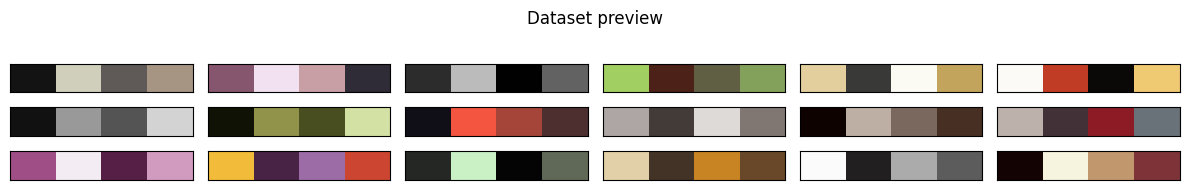

In [2]:
parquet_file = Path("../dataset/dataset.parquet")
if not parquet_file.exists():
    raise FileNotFoundError(f"Dataset file not found: {parquet_file.absolute()}")

df = pl.read_parquet(parquet_file)
color_cols = [f"color_{i}" for i in range(4)]
df = df.select(color_cols)

# Keep a manageable subset for microGPT training speed.
MAX_PALETTES = 1200000
df = df.head(MAX_PALETTES)


def hex_to_rgb(hex_str):
    if not isinstance(hex_str, str) or not hex_str.startswith("#") or len(hex_str) != 7:
        return None
    try:
        return tuple(int(hex_str[i : i + 2], 16) for i in (1, 3, 5))
    except ValueError:
        return None


rgb_palettes_list = []
for row in df.iter_rows(named=True):
    palette = []
    valid = True
    for col in color_cols:
        rgb = hex_to_rgb(row[col])
        if rgb is None:
            valid = False
            break
        palette.append(rgb)
    if valid:
        rgb_palettes_list.append(palette)

rgb_palettes_np = np.array(rgb_palettes_list, dtype=np.uint8)
print(f"Loaded {len(rgb_palettes_np)} valid palettes, shape={rgb_palettes_np.shape}")


def visualize_palettes(palettes, title="Palettes", n_cols=6):
    n_palettes = len(palettes)
    if n_palettes == 0:
        print("No palettes to display.")
        return
    n_rows = (n_palettes + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.0, n_rows * 0.65), squeeze=False)
    axes = axes.flatten()

    for i, palette in enumerate(palettes):
        normalized = [(r / 255.0, g / 255.0, b / 255.0) for r, g, b in palette]
        cmap = mcolors.ListedColormap(normalized)
        axes[i].imshow([list(range(len(palette)))], cmap=cmap, aspect="auto")
        axes[i].set_xticks([])
        axes[i].set_yticks([])

    for j in range(n_palettes, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


if len(rgb_palettes_list) > 0:
    visualize_palettes(rgb_palettes_list[:18], title="Dataset preview", n_cols=6)

## 2. OkLCH Tokenization

Convert RGB palettes to Oklab, transform to OkLCH, quantize into 128 bins per channel (`L`, `C`, `H`), then build token sequences with:
- `BOS` at start and end
- `SEP` between colors

Using C range [0, 0.2180] for quantization
Train docs: 92538, Val docs: 10282, Block size: 16


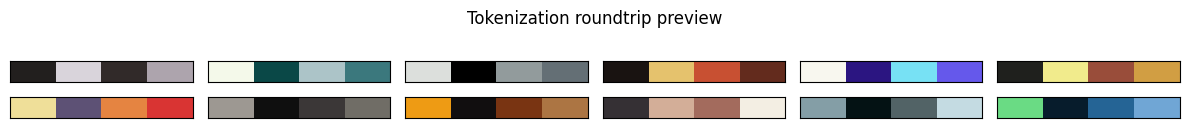

In [3]:
def rgb_to_oklab(rgb_uint8):
    linear_rgb = oklab.np_rgb_to_linear(rgb_uint8)
    return oklab.np_linear_srgb_to_oklab(linear_rgb)


def oklab_to_rgb(oklab_array):
    linear_rgb = oklab.np_oklab_to_linear_srgb(oklab_array)
    return oklab.np_linear_to_rgb(linear_rgb)


def oklab_to_oklch(oklab_array):
    l = oklab_array[..., 0]
    a = oklab_array[..., 1]
    b = oklab_array[..., 2]
    c = np.sqrt(a * a + b * b)
    h = (np.arctan2(b, a) % (2.0 * math.pi)) / (2.0 * math.pi)
    return np.stack((l, c, h), axis=-1)


def oklch_to_oklab(oklch_array):
    l = oklch_array[..., 0]
    c = oklch_array[..., 1]
    h = oklch_array[..., 2] * (2.0 * math.pi)
    a = c * np.cos(h)
    b = c * np.sin(h)
    return np.stack((l, a, b), axis=-1)


def quantize_to_bins(x, lo, hi, bins):
    x = np.clip(x, lo, hi)
    scaled = (x - lo) / max(hi - lo, 1e-12)
    return np.clip(np.round(scaled * (bins - 1)), 0, bins - 1).astype(np.int64)


def dequantize_from_bins(i, lo, hi, bins):
    return lo + (i.astype(np.float32) / (bins - 1)) * (hi - lo)


oklab_palettes = rgb_to_oklab(rgb_palettes_np)
oklch_palettes = oklab_to_oklch(oklab_palettes)

# L and H are naturally in [0,1] and [0,1). C is data-dependent.
C_MAX = float(np.quantile(oklch_palettes[..., 1], 0.995))
C_MAX = max(C_MAX, 1e-4)
print(f"Using C range [0, {C_MAX:.4f}] for quantization")

L_bins = quantize_to_bins(oklch_palettes[..., 0], 0.0, 1.0, NUM_BINS_L)
C_bins = quantize_to_bins(oklch_palettes[..., 1], 0.0, C_MAX, NUM_BINS_C)
H_bins = quantize_to_bins(oklch_palettes[..., 2], 0.0, 1.0, NUM_BINS_H)


def encode_palette_bins(l_bins, c_bins, h_bins):
    # Sequence format: BOS, LCH, SEP, LCH, SEP, LCH, SEP, LCH, BOS
    tokens = [BOS_TOKEN]
    for i in range(4):
        tokens.append(L_BASE + int(l_bins[i]))
        tokens.append(C_BASE + int(c_bins[i]))
        tokens.append(H_BASE + int(h_bins[i]))
        if i < 3:
            tokens.append(SEP_TOKEN)
    tokens.append(BOS_TOKEN)
    return tokens


def decode_palette_tokens(tokens):
    l_vals, c_vals, h_vals = [], [], []
    for t in tokens:
        if L_BASE <= t < C_BASE:
            l_vals.append(t - L_BASE)
        elif C_BASE <= t < H_BASE:
            c_vals.append(t - C_BASE)
        elif H_BASE <= t < BOS_TOKEN:
            h_vals.append(t - H_BASE)

    # Keep complete triplets only.
    n = min(len(l_vals), len(c_vals), len(h_vals), 4)
    if n == 0:
        return None

    l = dequantize_from_bins(np.array(l_vals[:n]), 0.0, 1.0, NUM_BINS_L)
    c = dequantize_from_bins(np.array(c_vals[:n]), 0.0, C_MAX, NUM_BINS_C)
    h = dequantize_from_bins(np.array(h_vals[:n]), 0.0, 1.0, NUM_BINS_H)
    oklch = np.stack((l, c, h), axis=-1)
    return oklch


docs = [
    encode_palette_bins(L_bins[i], C_bins[i], H_bins[i])
    for i in range(len(oklch_palettes))
]

random.shuffle(docs)
split_idx = int(0.9 * len(docs))
train_docs = docs[:split_idx]
val_docs = docs[split_idx:]

NUM_COLORS = len(color_cols)
TOKENS_PER_COLOR = 3
DOC_TOKEN_LENGTH = 1 + (NUM_COLORS * TOKENS_PER_COLOR) + max(NUM_COLORS - 1, 0) + 1
BLOCK_SIZE = DOC_TOKEN_LENGTH - 1
print(f"Train docs: {len(train_docs)}, Val docs: {len(val_docs)}, Block size: {BLOCK_SIZE}")

# Quick roundtrip sanity-check on a few palettes.
def tokens_to_rgb_palette(tokens):
    oklch = decode_palette_tokens(tokens)
    if oklch is None:
        return None
    oklab_array = oklch_to_oklab(oklch[None, ...])
    rgb = oklab_to_rgb(oklab_array)[0]
    return [tuple(map(int, x)) for x in rgb]

preview = [tokens_to_rgb_palette(docs[i]) for i in range(min(12, len(docs)))]
preview = [p for p in preview if p is not None]
if preview:
    visualize_palettes(preview, title="Tokenization roundtrip preview", n_cols=6)

## 3. Define microGPT Core (Pure Python Autograd)

This section ports the `microgpt.py` style architecture:
- scalar `Value` autograd
- RMSNorm + attention + MLP blocks
- no external deep learning framework

In [4]:
class Value:
    __slots__ = ("data", "grad", "_children", "_local_grads")

    def __init__(self, data, children=(), local_grads=()):
        self.data = float(data)
        self.grad = 0.0
        self._children = children
        self._local_grads = local_grads

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), (1.0, 1.0))

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self, other), (other.data, self.data))

    def __pow__(self, other):
        return Value(self.data ** other, (self,), (other * (self.data ** (other - 1)),))

    def log(self):
        return Value(math.log(self.data), (self,), (1.0 / self.data,))

    def exp(self):
        ex = math.exp(self.data)
        return Value(ex, (self,), (ex,))

    def relu(self):
        return Value(max(0.0, self.data), (self,), (float(self.data > 0.0),))

    def __neg__(self):
        return self * -1.0

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __truediv__(self, other):
        return self * (other ** -1)

    def __rtruediv__(self, other):
        return other * (self ** -1)

    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other

    def backward(self):
        topo = []
        visited = set()

        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build(child)
                topo.append(v)

        build(self)
        self.grad = 1.0
        for v in reversed(topo):
            for child, local_grad in zip(v._children, v._local_grads):
                child.grad += local_grad * v.grad


def matrix(nout, nin, std=0.08):
    return [[Value(random.gauss(0.0, std)) for _ in range(nin)] for _ in range(nout)]


def linear(x, w):
    return [sum(wi * xi for wi, xi in zip(row, x)) for row in w]


def softmax(logits):
    max_val = max(v.data for v in logits)
    exps = [(v - max_val).exp() for v in logits]
    total = sum(exps)
    return [e / total for e in exps]


def rmsnorm(x):
    ms = sum(xi * xi for xi in x) / len(x)
    scale = (ms + 1e-5) ** -0.5
    return [xi * scale for xi in x]


# microGPT model config (exact values from microgpt.py)
N_LAYER = 1
N_EMBD = 16
N_HEAD = 4
HEAD_DIM = N_EMBD // N_HEAD

state_dict = {
    "wte": matrix(VOCAB_SIZE, N_EMBD),
    "wpe": matrix(BLOCK_SIZE, N_EMBD),
    "lm_head": matrix(VOCAB_SIZE, N_EMBD),
}
for i in range(N_LAYER):
    state_dict[f"layer{i}.attn_wq"] = matrix(N_EMBD, N_EMBD)
    state_dict[f"layer{i}.attn_wk"] = matrix(N_EMBD, N_EMBD)
    state_dict[f"layer{i}.attn_wv"] = matrix(N_EMBD, N_EMBD)
    state_dict[f"layer{i}.attn_wo"] = matrix(N_EMBD, N_EMBD)
    state_dict[f"layer{i}.mlp_fc1"] = matrix(4 * N_EMBD, N_EMBD)
    state_dict[f"layer{i}.mlp_fc2"] = matrix(N_EMBD, 4 * N_EMBD)

params = [p for mat in state_dict.values() for row in mat for p in row]
print(f"Model parameters: {len(params):,}")


def gpt(token_id, pos_id, keys, values):
    tok_emb = state_dict["wte"][token_id]
    pos_emb = state_dict["wpe"][pos_id]
    x = [t + p for t, p in zip(tok_emb, pos_emb)]
    x = rmsnorm(x)

    for li in range(N_LAYER):
        x_res = x
        x = rmsnorm(x)

        q = linear(x, state_dict[f"layer{li}.attn_wq"])
        k = linear(x, state_dict[f"layer{li}.attn_wk"])
        v = linear(x, state_dict[f"layer{li}.attn_wv"])
        keys[li].append(k)
        values[li].append(v)

        x_attn = []
        for h in range(N_HEAD):
            hs = h * HEAD_DIM
            q_h = q[hs : hs + HEAD_DIM]
            k_h = [kt[hs : hs + HEAD_DIM] for kt in keys[li]]
            v_h = [vt[hs : hs + HEAD_DIM] for vt in values[li]]

            logits = [sum(q_h[j] * k_h[t][j] for j in range(HEAD_DIM)) / (HEAD_DIM ** 0.5) for t in range(len(k_h))]
            w = softmax(logits)
            out_h = [sum(w[t] * v_h[t][j] for t in range(len(v_h))) for j in range(HEAD_DIM)]
            x_attn.extend(out_h)

        x = linear(x_attn, state_dict[f"layer{li}.attn_wo"])
        x = [a + b for a, b in zip(x, x_res)]

        x_res = x
        x = rmsnorm(x)
        x = linear(x, state_dict[f"layer{li}.mlp_fc1"])
        x = [xi.relu() for xi in x]
        x = linear(x, state_dict[f"layer{li}.mlp_fc2"])
        x = [a + b for a, b in zip(x, x_res)]

    return linear(x, state_dict["lm_head"])

Model parameters: 7,424


## 4. Train the Model

Train with Adam (as in `microgpt.py`) on tokenized palette sequences.
Validation loss is tracked periodically on held-out docs.

Training microGPT:   0%|          | 0/1000 [00:00<?, ?step/s]

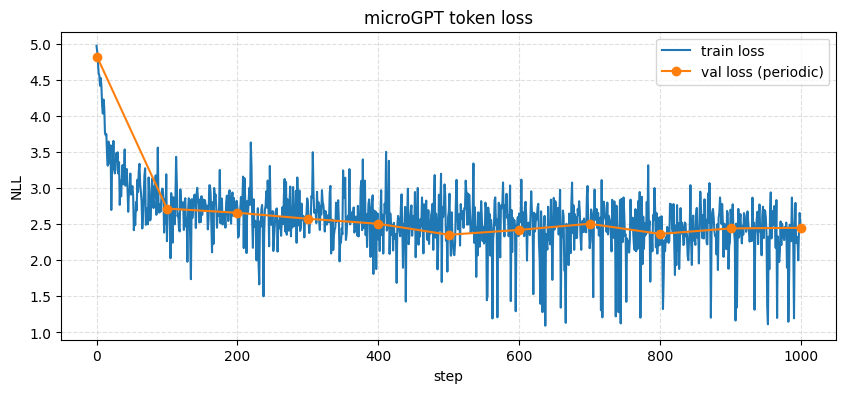

In [5]:
from tqdm.auto import tqdm

# Adam setup (exact values from microgpt.py)
learning_rate = 0.01
beta1, beta2 = 0.85, 0.99
eps_adam = 1e-8

num_steps = 1000
eval_every = 100
val_batches = 32

def sequence_loss(tokens):
    n = min(BLOCK_SIZE, len(tokens) - 1)
    keys = [[] for _ in range(N_LAYER)]
    values = [[] for _ in range(N_LAYER)]
    losses = []
    for pos_id in range(n):
        token_id = tokens[pos_id]
        target_id = tokens[pos_id + 1]
        logits = gpt(token_id, pos_id, keys, values)
        probs = softmax(logits)
        losses.append(-probs[target_id].log())
    return (1.0 / n) * sum(losses)


def estimate_split_loss(split_docs, max_docs=32):
    if len(split_docs) == 0:
        return float("nan")
    k = min(max_docs, len(split_docs))
    sampled = random.sample(split_docs, k)
    vals = []
    for seq in sampled:
        l = sequence_loss(seq)
        vals.append(l.data)
    return float(np.mean(vals))


m = [0.0] * len(params)
v = [0.0] * len(params)

train_curve = []
val_curve = []
last_val_loss = float("nan")

pbar = tqdm(range(num_steps), desc="Training microGPT", unit="step")
for step in pbar:
    doc = train_docs[step % len(train_docs)]
    loss = sequence_loss(doc)
    loss.backward()

    lr_t = learning_rate * (1.0 - step / num_steps)
    for i, p in enumerate(params):
        g = p.grad
        m[i] = beta1 * m[i] + (1.0 - beta1) * g
        v[i] = beta2 * v[i] + (1.0 - beta2) * (g * g)
        m_hat = m[i] / (1.0 - beta1 ** (step + 1))
        v_hat = v[i] / (1.0 - beta2 ** (step + 1))
        p.data -= lr_t * m_hat / (v_hat ** 0.5 + eps_adam)
        p.grad = 0.0

    train_curve.append(loss.data)

    if (step + 1) % eval_every == 0 or step == 0:
        last_val_loss = estimate_split_loss(val_docs, max_docs=val_batches)
        val_curve.append((step + 1, last_val_loss))

    pbar.set_postfix({
        "train_loss": f"{loss.data:.4f}",
        "val_loss": f"{last_val_loss:.4f}" if not np.isnan(last_val_loss) else "-",
        "lr": f"{lr_t:.5f}",
    })


plt.figure(figsize=(10, 4))
plt.plot(train_curve, label="train loss")
if len(val_curve) > 0:
    xs, ys = zip(*val_curve)
    plt.plot(xs, ys, "o-", label="val loss (periodic)")
plt.title("microGPT token loss")
plt.xlabel("step")
plt.ylabel("NLL")
plt.grid(alpha=0.4, linestyle="--")
plt.legend()
plt.show()

## 5. Validation and Palette Sampling

Run final validation, then autoregressively sample new token sequences.
Each sample is decoded from tokens -> OkLCH -> Oklab -> RGB and visualized.

In [6]:
def sample_tokens(max_len=BLOCK_SIZE, temperature=0.8):
    keys = [[] for _ in range(N_LAYER)]
    values = [[] for _ in range(N_LAYER)]

    seq = [BOS_TOKEN]
    token_id = BOS_TOKEN

    for pos_id in range(max_len):
        logits = gpt(token_id, pos_id, keys, values)
        probs = softmax([l / temperature for l in logits])
        weights = [p.data for p in probs]
        token_id = random.choices(range(VOCAB_SIZE), weights=weights)[0]
        seq.append(token_id)
        if token_id == BOS_TOKEN:
            break

    return seq


def strip_special(seq):
    # Remove leading/trailing BOS for decoding convenience.
    out = [t for t in seq if t != BOS_TOKEN]
    return out


final_train = estimate_split_loss(train_docs, max_docs=64)
final_val = estimate_split_loss(val_docs, max_docs=64)
print(f"Final train loss: {final_train:.4f}")
print(f"Final val loss:   {final_val:.4f}")



Final train loss: 2.4596
Final val loss:   2.3822


Decoded 24 valid palettes from 24 samples


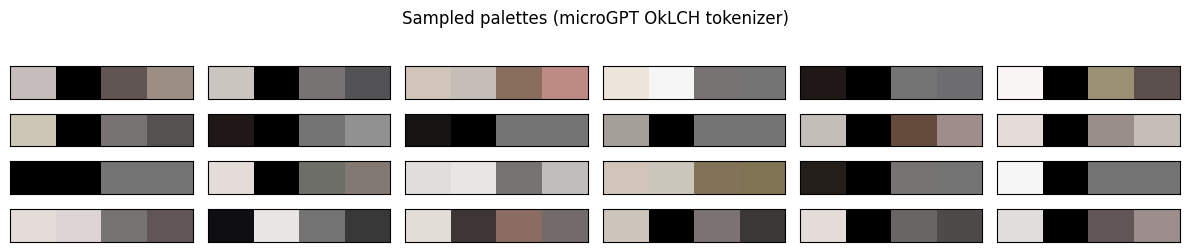

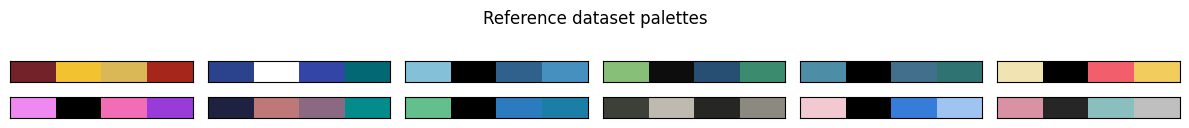

In [7]:
num_samples = 24
sampled_rgb = []

for _ in range(num_samples):
    seq = sample_tokens(temperature=0.20)
    palette_rgb = tokens_to_rgb_palette(strip_special(seq))
    if palette_rgb is not None and len(palette_rgb) >= 4:
        sampled_rgb.append(palette_rgb[:4])

print(f"Decoded {len(sampled_rgb)} valid palettes from {num_samples} samples")
if sampled_rgb:
    visualize_palettes(sampled_rgb, title="Sampled palettes (microGPT OkLCH tokenizer)", n_cols=6)

# Compare with a small set from the dataset for visual sanity.
if len(rgb_palettes_list) >= 12:
    visualize_palettes(rgb_palettes_list[:12], title="Reference dataset palettes", n_cols=6)

Decoded 23 valid palettes from 24 clean-context samples


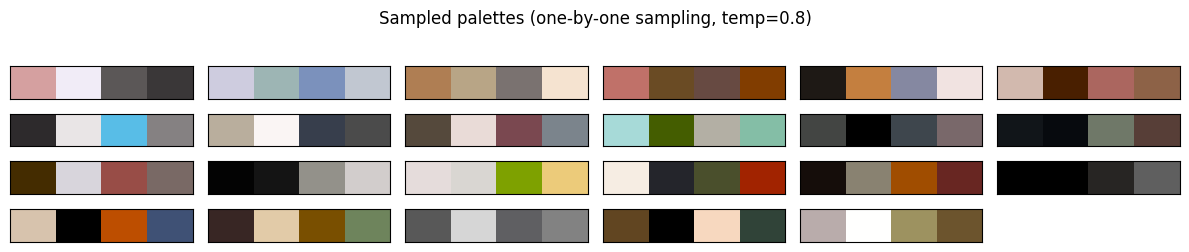

In [8]:
num_samples_clean = 24
sampled_rgb_clean = []

# Beginner-friendly version: generate one palette at a time.
for _ in range(num_samples_clean):
    # Each call starts a new sequence from BOS inside sample_tokens().
    seq = sample_tokens(temperature=0.8)

    palette_rgb = tokens_to_rgb_palette(strip_special(seq))
    if palette_rgb is not None and len(palette_rgb) >= 4:
        sampled_rgb_clean.append(palette_rgb[:4])

print(f"Decoded {len(sampled_rgb_clean)} valid palettes from {num_samples_clean} clean-context samples")
if sampled_rgb_clean:
    visualize_palettes(
        sampled_rgb_clean,
        title="Sampled palettes (one-by-one sampling, temp=0.8)",
        n_cols=6,
    )

In [9]:
def random_vibrant_oklch_color():
    # Random vivid seed color in OkLCH space.
    l = random.uniform(0.50, 0.82)
    c_low = min(max(0.08, 0.55 * C_MAX), C_MAX)
    c_high = C_MAX
    if c_low >= c_high:
        c_low = 0.5 * c_high
    c = random.uniform(c_low, c_high)
    h = random.random()
    return np.array([l, c, h], dtype=np.float32)


def oklch_color_to_tokens(oklch_color):
    l_bin = int(quantize_to_bins(np.array([oklch_color[0]]), 0.0, 1.0, NUM_BINS_L)[0])
    c_bin = int(quantize_to_bins(np.array([oklch_color[1]]), 0.0, C_MAX, NUM_BINS_C)[0])
    h_bin = int(quantize_to_bins(np.array([oklch_color[2]]), 0.0, 1.0, NUM_BINS_H)[0])
    return [L_BASE + l_bin, C_BASE + c_bin, H_BASE + h_bin]


def sample_tokens_from_prefix(prefix_tokens, max_len=BLOCK_SIZE, temperature=0.8):
    # Start from a clean context for each palette, then prime with the prefix.
    keys = [[] for _ in range(N_LAYER)]
    values = [[] for _ in range(N_LAYER)]
    seq = list(prefix_tokens)

    if len(seq) == 0:
        return [BOS_TOKEN]

    # Feed the prefix token-by-token so the next sample is conditioned on it.
    logits = None
    for pos_id, token_id in enumerate(seq):
        if pos_id >= max_len:
            return seq
        logits = gpt(token_id, pos_id, keys, values)

    while len(seq) <= max_len:
        probs = softmax([l / temperature for l in logits])
        weights = [p.data for p in probs]
        token_id = random.choices(range(VOCAB_SIZE), weights=weights)[0]
        seq.append(token_id)

        if token_id == BOS_TOKEN:
            break

        pos_id = len(seq) - 1
        if pos_id >= max_len:
            break
        logits = gpt(token_id, pos_id, keys, values)

    return seq


num_samples_prefill = 24
sampled_rgb_prefill = []

# Beginner-friendly loop: one seeded palette at a time.
for _ in range(num_samples_prefill):
    first_oklch = random_vibrant_oklch_color()
    first_tokens = oklch_color_to_tokens(first_oklch)

    # Prefix format: BOS, first color (L C H), SEP, then model generates the rest.
    prefix = [BOS_TOKEN, first_tokens[0], first_tokens[1], first_tokens[2], SEP_TOKEN]
    seq = sample_tokens_from_prefix(prefix, temperature=0.8)

    palette_rgb = tokens_to_rgb_palette(strip_special(seq))
    if palette_rgb is not None and len(palette_rgb) >= 4:
        sampled_rgb_prefill.append(palette_rgb[:4])

print(f"Decoded {len(sampled_rgb_prefill)} valid palettes from {num_samples_prefill} prefilled samples")
#if sampled_rgb_prefill:
#    visualize_palettes(
#        sampled_rgb_prefill,
#        title="Sampled palettes (prefilled first vibrant color, temp=0.8)",
#        n_cols=6,
#    )

Decoded 24 valid palettes from 24 prefilled samples


## 6. Faster Inference (Reuse Trained Weights)

This section keeps the model weights learned above, but converts them to NumPy arrays for inference only.

Why this is faster:
- no `Value` object creation during sampling,
- no autograd graph construction,
- vectorized matrix multiplications.

Training remains unchanged; this is only a faster sampler path.

In [10]:
import time


def value_matrix_to_numpy(mat):
    return np.array([[v.data for v in row] for row in mat], dtype=np.float32)


def build_fast_state_from_value_state(value_state):
    fast = {
        "wte": value_matrix_to_numpy(value_state["wte"]),
        "wpe": value_matrix_to_numpy(value_state["wpe"]),
        "lm_head": value_matrix_to_numpy(value_state["lm_head"]),
        "layers": [],
    }
    for li in range(N_LAYER):
        fast["layers"].append(
            {
                "attn_wq": value_matrix_to_numpy(value_state[f"layer{li}.attn_wq"]),
                "attn_wk": value_matrix_to_numpy(value_state[f"layer{li}.attn_wk"]),
                "attn_wv": value_matrix_to_numpy(value_state[f"layer{li}.attn_wv"]),
                "attn_wo": value_matrix_to_numpy(value_state[f"layer{li}.attn_wo"]),
                "mlp_fc1": value_matrix_to_numpy(value_state[f"layer{li}.mlp_fc1"]),
                "mlp_fc2": value_matrix_to_numpy(value_state[f"layer{li}.mlp_fc2"]),
            }
        )
    return fast


def softmax_np(x):
    z = x - np.max(x)
    e = np.exp(z)
    return e / np.sum(e)


def rmsnorm_np(x, eps=1e-5):
    return x * (np.mean(x * x) + eps) ** -0.5


def init_kv_cache_fast(max_len=BLOCK_SIZE):
    cache = []
    for _ in range(N_LAYER):
        cache.append(
            {
                "k": np.zeros((max_len, N_EMBD), dtype=np.float32),
                "v": np.zeros((max_len, N_EMBD), dtype=np.float32),
                "t": 0,
            }
        )
    return cache


def gpt_step_fast(token_id, pos_id, kv_cache, fast_state):
    x = fast_state["wte"][token_id] + fast_state["wpe"][pos_id]
    x = rmsnorm_np(x)

    for li in range(N_LAYER):
        layer = fast_state["layers"][li]
        x_res = x
        x = rmsnorm_np(x)

        q = layer["attn_wq"] @ x
        k = layer["attn_wk"] @ x
        v = layer["attn_wv"] @ x

        layer_cache = kv_cache[li]
        t = layer_cache["t"]
        layer_cache["k"][t] = k
        layer_cache["v"][t] = v
        layer_cache["t"] = t + 1

        x_attn_parts = []
        for h in range(N_HEAD):
            hs = h * HEAD_DIM
            he = hs + HEAD_DIM

            q_h = q[hs:he]
            k_h = layer_cache["k"][: t + 1, hs:he]
            v_h = layer_cache["v"][: t + 1, hs:he]

            logits = (k_h @ q_h) / (HEAD_DIM ** 0.5)
            w = softmax_np(logits)
            out_h = w @ v_h
            x_attn_parts.append(out_h)

        x_attn = np.concatenate(x_attn_parts, axis=0)
        x = layer["attn_wo"] @ x_attn
        x = x + x_res

        x_res = x
        x = rmsnorm_np(x)
        x = layer["mlp_fc1"] @ x
        x = np.maximum(x, 0.0)
        x = layer["mlp_fc2"] @ x
        x = x + x_res

    return fast_state["lm_head"] @ x


def sample_tokens_fast(max_len=BLOCK_SIZE, temperature=0.8):
    kv_cache = init_kv_cache_fast(max_len=max_len)
    seq = [BOS_TOKEN]
    token_id = BOS_TOKEN

    for pos_id in range(max_len):
        logits = gpt_step_fast(token_id, pos_id, kv_cache, fast_state)
        probs = softmax_np(logits / max(temperature, 1e-6))
        token_id = int(np.random.choice(VOCAB_SIZE, p=probs))
        seq.append(token_id)
        if token_id == BOS_TOKEN:
            break

    return seq


def sample_tokens_from_prefix_fast(prefix_tokens, max_len=BLOCK_SIZE, temperature=0.8):
    kv_cache = init_kv_cache_fast(max_len=max_len)
    seq = list(prefix_tokens)

    if len(seq) == 0:
        return [BOS_TOKEN]

    logits = None
    for pos_id, token_id in enumerate(seq):
        if pos_id >= max_len:
            return seq
        logits = gpt_step_fast(token_id, pos_id, kv_cache, fast_state)

    while len(seq) <= max_len:
        probs = softmax_np(logits / max(temperature, 1e-6))
        token_id = int(np.random.choice(VOCAB_SIZE, p=probs))
        seq.append(token_id)

        if token_id == BOS_TOKEN:
            break

        pos_id = len(seq) - 1
        if pos_id >= max_len:
            break
        logits = gpt_step_fast(token_id, pos_id, kv_cache, fast_state)

    return seq


fast_state = build_fast_state_from_value_state(state_dict)
print("Fast inference state initialized from trained weights.")

# Small benchmark (keep runs modest so this cell stays interactive).
benchmark_runs = 8

start_slow = time.perf_counter()
for _ in range(benchmark_runs):
    _ = sample_tokens(temperature=0.8)
slow_s = time.perf_counter() - start_slow

start_fast = time.perf_counter()
for _ in range(benchmark_runs):
    _ = sample_tokens_fast(temperature=0.8)
fast_s = time.perf_counter() - start_fast

print(f"Slow sampler: {slow_s:.3f}s for {benchmark_runs} samples ({1000*slow_s/benchmark_runs:.1f} ms/sample)")
print(f"Fast sampler: {fast_s:.3f}s for {benchmark_runs} samples ({1000*fast_s/benchmark_runs:.1f} ms/sample)")
if fast_s > 0:
    print(f"Speedup: {slow_s / fast_s:.2f}x")

Fast inference state initialized from trained weights.
Slow sampler: 3.882s for 8 samples (485.2 ms/sample)
Fast sampler: 0.008s for 8 samples (1.0 ms/sample)
Speedup: 469.77x


Decoded 4 valid palettes from 24 fast samples


/var/folders/mw/6xkrr4cj0vb6vd47061831_40000gn/T/ipykernel_99229/8856931.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


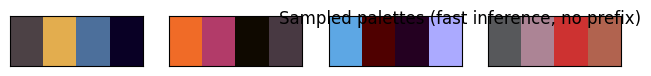

In [11]:
num_samples_fast = 24
sampled_rgb_fast = []

# Fast inference, no prefix: each palette starts from BOS.
for _ in range(num_samples_fast):
    seq = sample_tokens_fast(temperature=2.9)
    palette_rgb = tokens_to_rgb_palette(strip_special(seq))
    if palette_rgb is not None and len(palette_rgb) >= 4:
        sampled_rgb_fast.append(palette_rgb[:4])

print(f"Decoded {len(sampled_rgb_fast)} valid palettes from {num_samples_fast} fast samples")
if sampled_rgb_fast:
    visualize_palettes(
        sampled_rgb_fast,
        title="Sampled palettes (fast inference, no prefix)",
        n_cols=6,
    )

Decoded 24 valid palettes from 24 dynamic-temperature samples


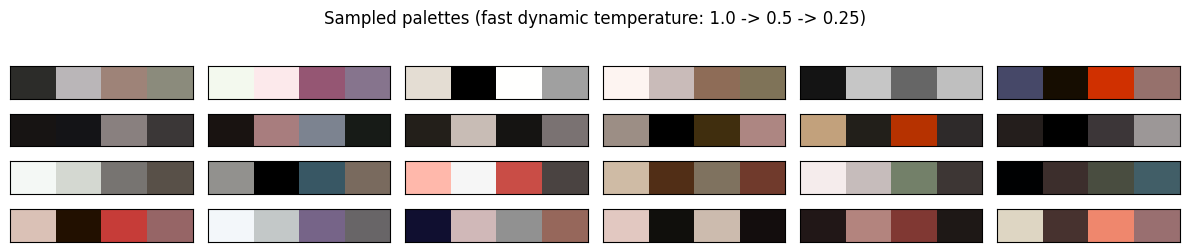

In [12]:
def temperature_from_palette_progress(seq, t_first=1.0, t_middle=0.5, t_last=0.25):
    # Count completed colors using SEP tokens in the generated sequence.
    completed_colors = seq.count(SEP_TOKEN)
    if completed_colors == 0:
        return t_first      # first color
    if completed_colors >= 3:
        return t_last       # fourth (last) color and ending token
    return t_middle         # second and third colors


def sample_tokens_fast_dynamic_temperature(max_len=BLOCK_SIZE, t_first=1.0, t_middle=0.5, t_last=0.25):
    kv_cache = init_kv_cache_fast(max_len=max_len)
    seq = [BOS_TOKEN]
    token_id = BOS_TOKEN

    for pos_id in range(max_len):
        logits = gpt_step_fast(token_id, pos_id, kv_cache, fast_state)

        temp = temperature_from_palette_progress(seq, t_first=t_first, t_middle=t_middle, t_last=t_last)
        probs = softmax_np(logits / max(temp, 1e-6))

        token_id = int(np.random.choice(VOCAB_SIZE, p=probs))
        seq.append(token_id)
        if token_id == BOS_TOKEN:
            break

    return seq


num_samples_dynamic = 24
sampled_rgb_dynamic = []

for _ in range(num_samples_dynamic):
    seq = sample_tokens_fast_dynamic_temperature(
        t_first=1.0,
        t_middle=0.75,
        t_last=0.5,
    )
    palette_rgb = tokens_to_rgb_palette(strip_special(seq))
    if palette_rgb is not None and len(palette_rgb) >= 4:
        sampled_rgb_dynamic.append(palette_rgb[:4])

print(f"Decoded {len(sampled_rgb_dynamic)} valid palettes from {num_samples_dynamic} dynamic-temperature samples")
if sampled_rgb_dynamic:
    visualize_palettes(
        sampled_rgb_dynamic,
        title="Sampled palettes (fast dynamic temperature: 1.0 -> 0.5 -> 0.25)",
        n_cols=6,
    )

Decoded 24 valid palettes from 24 prefilled dynamic-temperature samples


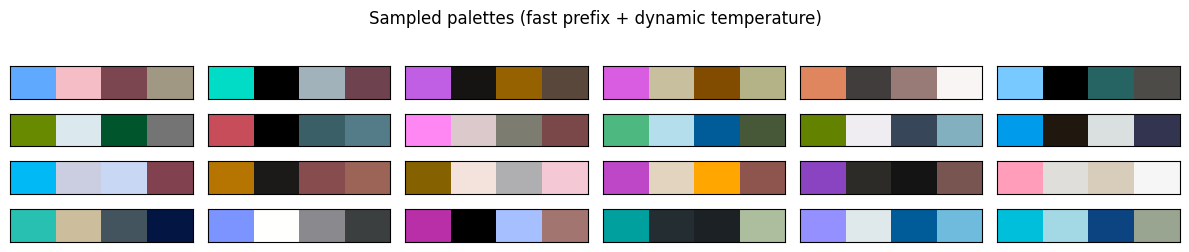

In [13]:
def sample_tokens_from_prefix_fast_dynamic_temperature(
    prefix_tokens,
    max_len=BLOCK_SIZE,
    t_first=1.0,
    t_middle=0.5,
    t_last=0.25,
):
    kv_cache = init_kv_cache_fast(max_len=max_len)
    seq = list(prefix_tokens)

    if len(seq) == 0:
        return [BOS_TOKEN]

    logits = None
    for pos_id, token_id in enumerate(seq):
        if pos_id >= max_len:
            return seq
        logits = gpt_step_fast(token_id, pos_id, kv_cache, fast_state)

    while len(seq) <= max_len:
        temp = temperature_from_palette_progress(
            seq,
            t_first=t_first,
            t_middle=t_middle,
            t_last=t_last,
        )
        probs = softmax_np(logits / max(temp, 1e-6))
        token_id = int(np.random.choice(VOCAB_SIZE, p=probs))
        seq.append(token_id)

        if token_id == BOS_TOKEN:
            break

        pos_id = len(seq) - 1
        if pos_id >= max_len:
            break
        logits = gpt_step_fast(token_id, pos_id, kv_cache, fast_state)

    return seq


num_samples_prefill_dynamic = 24
sampled_rgb_prefill_dynamic = []

for _ in range(num_samples_prefill_dynamic):
    first_oklch = random_vibrant_oklch_color()
    first_tokens = oklch_color_to_tokens(first_oklch)
    prefix = [BOS_TOKEN, first_tokens[0], first_tokens[1], first_tokens[2], SEP_TOKEN]

    seq = sample_tokens_from_prefix_fast_dynamic_temperature(
        prefix,
        t_first=1.0,
        t_middle=0.7,
        t_last=0.6,
    )
    palette_rgb = tokens_to_rgb_palette(strip_special(seq))
    if palette_rgb is not None and len(palette_rgb) >= 4:
        sampled_rgb_prefill_dynamic.append(palette_rgb[:4])

print(
    f"Decoded {len(sampled_rgb_prefill_dynamic)} valid palettes from "
    f"{num_samples_prefill_dynamic} prefilled dynamic-temperature samples"
)
if sampled_rgb_prefill_dynamic:
    visualize_palettes(
        sampled_rgb_prefill_dynamic,
        title="Sampled palettes (fast prefix + dynamic temperature)",
        n_cols=6,
    )